In [ ]:
import pandas as pd
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Representasi koordinat Jakarta
URL = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": -6.200000,
    "longitude": 106.816666,
    "start_date": "2021-01-01",
    "end_date": "2026-01-01",
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "wind_speed_10m_max", "relative_humidity_2m_max"],
    "timezone": "Asia/Jakarta"
}

response = requests.get(URL, params=params)
data = response.json()

# Mengubah ke DataFrame Pandas
df = pd.DataFrame(data["daily"])
print(df.head())

         time  temperature_2m_max  temperature_2m_min  precipitation_sum  \
0  2021-01-01                29.6                23.5               11.2   
1  2021-01-02                29.6                23.8                3.6   
2  2021-01-03                30.6                24.1                6.0   
3  2021-01-04                29.6                23.5                1.7   
4  2021-01-05                28.4                23.5               10.1   

   wind_speed_10m_max  relative_humidity_2m_max  
0                14.6                        97  
1                10.5                        93  
2                14.8                        95  
3                13.0                        98  
4                 9.0                        97  


In [ ]:
df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_max
0,2021-01-01,29.6,23.5,11.2,14.6,97
1,2021-01-02,29.6,23.8,3.6,10.5,93
2,2021-01-03,30.6,24.1,6.0,14.8,95
3,2021-01-04,29.6,23.5,1.7,13.0,98
4,2021-01-05,28.4,23.5,10.1,9.0,97


## Data Assertions

In [ ]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time                      1827 non-null   object 
 1   temperature_2m_max        1827 non-null   float64
 2   temperature_2m_min        1827 non-null   float64
 3   precipitation_sum         1827 non-null   float64
 4   wind_speed_10m_max        1827 non-null   float64
 5   relative_humidity_2m_max  1827 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 85.8+ KB


In [ ]:
# cek missing values
df.isnull().sum().sort_values(ascending=False)

,0
time,0
temperature_2m_max,0
temperature_2m_min,0
precipitation_sum,0
wind_speed_10m_max,0
relative_humidity_2m_max,0


In [ ]:
# Baris terduplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
# memeriksa apakah data kelembapan sesuai pada rentang 0-100
df[(df['relative_humidity_2m_max'] >= 0) | (df['relative_humidity_2m_max'] <= 100)]

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_max
0,2021-01-01,29.6,23.5,11.2,14.6,97
1,2021-01-02,29.6,23.8,3.6,10.5,93
2,2021-01-03,30.6,24.1,6.0,14.8,95
3,2021-01-04,29.6,23.5,1.7,13.0,98
4,2021-01-05,28.4,23.5,10.1,9.0,97
...,...,...,...,...,...,...
1822,2025-12-28,32.5,25.9,11.2,14.3,85
1823,2025-12-29,32.9,25.1,1.2,11.9,87
1824,2025-12-30,31.9,24.5,35.4,13.0,97
1825,2025-12-31,28.5,23.6,36.0,12.9,97


## Data Preprocessing

In [ ]:
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

In [ ]:
df

,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_max
time,,,,,
2021-01-01,29.6,23.5,11.2,14.6,97
2021-01-02,29.6,23.8,3.6,10.5,93
2021-01-03,30.6,24.1,6.0,14.8,95
2021-01-04,29.6,23.5,1.7,13.0,98
2021-01-05,28.4,23.5,10.1,9.0,97
...,...,...,...,...,...
2025-12-28,32.5,25.9,11.2,14.3,85
2025-12-29,32.9,25.1,1.2,11.9,87
2025-12-30,31.9,24.5,35.4,13.0,97


In [ ]:
# membuat feature curah hujan besok
df['precipitation_sum_besok'] = df['precipitation_sum'].shift(-1)
df.head()

,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_max,precipitation_sum_besok
time,,,,,,
2021-01-01,29.6,23.5,11.2,14.6,97,3.6
2021-01-02,29.6,23.8,3.6,10.5,93,6.0
2021-01-03,30.6,24.1,6.0,14.8,95,1.7
2021-01-04,29.6,23.5,1.7,13.0,98,10.1
2021-01-05,28.4,23.5,10.1,9.0,97,25.3


In [ ]:
df.tail()

,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_max,precipitation_sum_besok
time,,,,,,
2025-12-28,32.5,25.9,11.2,14.3,85,1.2
2025-12-29,32.9,25.1,1.2,11.9,87,35.4
2025-12-30,31.9,24.5,35.4,13.0,97,36.0
2025-12-31,28.5,23.6,36.0,12.9,97,9.5
2026-01-01,30.2,23.6,9.5,12.0,97,NaN


In [ ]:
# membuat kolom hujan besok
df['hujan_besok'] = (df['precipitation_sum_besok'] > 0.5).astype(int)

In [ ]:
df

,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_max,precipitation_sum_besok,hujan_besok
time,,,,,,,
2021-01-01,29.6,23.5,11.2,14.6,97,3.6,1
2021-01-02,29.6,23.8,3.6,10.5,93,6.0,1
2021-01-03,30.6,24.1,6.0,14.8,95,1.7,1
2021-01-04,29.6,23.5,1.7,13.0,98,10.1,1
2021-01-05,28.4,23.5,10.1,9.0,97,25.3,1
...,...,...,...,...,...,...,...
2025-12-28,32.5,25.9,11.2,14.3,85,1.2,1
2025-12-29,32.9,25.1,1.2,11.9,87,35.4,1
2025-12-30,31.9,24.5,35.4,13.0,97,36.0,1


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop(columns=['precipitation_sum_besok'], inplace=True)

In [ ]:
df

,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_max,precipitation_sum_besok,hujan_besok
time,,,,,,,
2021-01-01,29.6,23.5,11.2,14.6,97,3.6,1
2021-01-02,29.6,23.8,3.6,10.5,93,6.0,1
2021-01-03,30.6,24.1,6.0,14.8,95,1.7,1
2021-01-04,29.6,23.5,1.7,13.0,98,10.1,1
2021-01-05,28.4,23.5,10.1,9.0,97,25.3,1
...,...,...,...,...,...,...,...
2025-12-27,32.0,25.7,1.0,18.5,87,11.2,1
2025-12-28,32.5,25.9,11.2,14.3,85,1.2,1
2025-12-29,32.9,25.1,1.2,11.9,87,35.4,1


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
temperature_2m_max,0
temperature_2m_min,0
precipitation_sum,0
wind_speed_10m_max,0
relative_humidity_2m_max,0
precipitation_sum_besok,0
hujan_besok,0


## EDA

In [ ]:
df['hujan_besok'].value_counts(normalize=True)

,proportion
hujan_besok,
1,0.836802
0,0.163198


In [ ]:
df['hujan_besok'].value_counts()

,count
hujan_besok,
1,1528
0,298


In [ ]:
# korelasi antar feature dengan target
df.corr()['hujan_besok'].sort_values(ascending=False)

,hujan_besok
hujan_besok,1.000000
precipitation_sum_besok,0.360638
relative_humidity_2m_max,0.269290
precipitation_sum,0.239391
temperature_2m_min,0.138741
wind_speed_10m_max,-0.153497
temperature_2m_max,-0.279255


## Training Preparation

In [ ]:
X = df.drop(columns=['hujan_besok'])
y = df['hujan_besok']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

## Model Evaluation

In [ ]:
# classfication report
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.30      0.37        60
           1       0.87      0.94      0.90       306

    accuracy                           0.83       366
   macro avg       0.68      0.62      0.64       366
weighted avg       0.81      0.83      0.82       366



Text(50.722222222222214, 0.5, 'Actual')

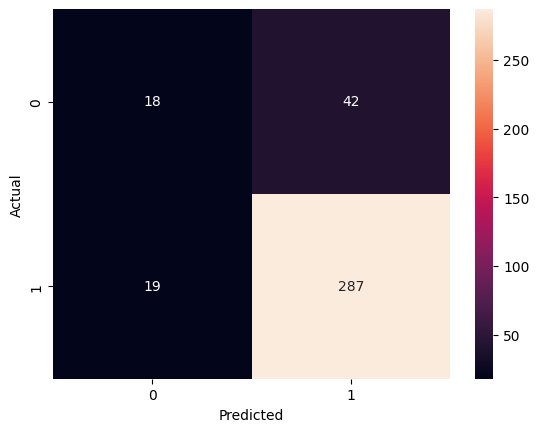

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [ ]:
# export model
with open('trained_rf.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
# export scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)